# Logistic Regression Classifier Workshop

**Course**: CSCN8010 - Statistical Machine Learning
**Group**: 2

**Group Members:**
- **Ali Cihan Ozdemir** (Lead Developer) - Student Number: 9091405
- **Danda, Lohith Reddy** (Contributor) - Student Number: 9054470
- **Roshan Bartaula** - No contribution (did not attend class)

**Date**: February 14, 2026

## 0. Introduction

This workshop implements a Logistic Regression classifier to predict Pass/Fail outcomes based on study hours. The project demonstrates:
- Statistical classification fundamentals
- Binary classification using Logistic Regression
- SQLite database integration for data persistence
- Real-time streaming with 2-second intervals
- Dynamic dashboard with IPyWidgets

---

## 1. Setup and Imports

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import time
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import ipywidgets as widgets
from IPython.display import display, clear_output

---

## 2. Pipeline Functions

### 2.1 load_data()

This function loads the study hours dataset. It creates a sample dataset of students with their study hours and pass/fail outcomes. The data is also stored in a SQLite database for persistence.

In [30]:
def load_data():
    """
    Load or create the study hours dataset.
    
    Returns:
    tuple: (hours_studied array, pass_fail array)
    """
    hours_studied = np.array([0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 
                               3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75, 5, 5.5, 6, 6.5, 7, 7.5, 8]).reshape(-1, 1)
    pass_fail = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
    
    return hours_studied, pass_fail

### 2.2 preprocess_data()

This function prepares the data for training. It splits the data into training and testing sets for model evaluation.

In [31]:
def preprocess_data(hours_studied, pass_fail, test_size=0.2, random_state=42):
    """
    Preprocess the data by splitting into train and test sets.
    
    Parameters:
    hours_studied: Feature array (study hours)
    pass_fail: Target array (pass/fail labels)
    test_size: Proportion of data for testing
    random_state: Random seed for reproducibility
    
    Returns:
    tuple: (X_train, X_test, y_train, y_test)
    """
    X_train, X_test, y_train, y_test = train_test_split(
        hours_studied, pass_fail, test_size=test_size, random_state=random_state
    )
    return X_train, X_test, y_train, y_test

### 2.3 train_model()

This function trains the Logistic Regression model using scikit-learn. The model learns the relationship between study hours and pass/fail outcomes.

In [32]:
def train_model(X_train, y_train):
    """
    Train a Logistic Regression model.
    
    Parameters:
    X_train: Training features (study hours)
    y_train: Training labels (pass/fail)
    
    Returns:
    LogisticRegression: Trained model
    """
    model = LogisticRegression(random_state=42)
    model.fit(X_train, y_train)
    return model

### 2.4 evaluate_model()

This function evaluates the trained model using various metrics: accuracy, log-loss, and confusion matrix. These metrics help assess the model's performance.

In [33]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate the trained model using various metrics.
    
    Parameters:
    model: Trained Logistic Regression model
    X_test: Test features
    y_test: Test labels
    
    Returns:
    dict: Dictionary containing evaluation metrics
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'log_loss': log_loss(y_test, y_prob),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'predictions': y_pred,
        'probabilities': y_prob
    }
    
    return metrics

---

## 3. Database Setup (SQLite)

This section creates and populates the SQLite database with historical study records. The database stores student study hours and their pass/fail outcomes for persistence.

In [34]:
def setup_database(db_name='study_records.db'):
    """
    Create and populate the SQLite database with study records.
    
    Parameters:
    db_name: Name of the SQLite database file
    """
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS study_records (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            hours_studied REAL NOT NULL,
            pass_fail INTEGER NOT NULL,
            timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
        )
    ''')
    
    hours_studied, pass_fail = load_data()
    
    cursor.execute('DELETE FROM study_records')
    
    for i, (hours, result) in enumerate(zip(hours_studied.flatten(), pass_fail)):
        cursor.execute(
            'INSERT INTO study_records (hours_studied, pass_fail) VALUES (?, ?)',
            (float(hours), int(result))
        )
    
    conn.commit()
    conn.close()
    print(f"Database '{db_name}' created and populated with {len(pass_fail)} records.")

setup_database()

Database 'study_records.db' created and populated with 25 records.


---

## 4. Model Training and Evaluation

In [35]:
hours_studied, pass_fail = load_data()
X_train, X_test, y_train, y_test = preprocess_data(hours_studied, pass_fail)
model = train_model(X_train, y_train)
metrics = evaluate_model(model, X_test, y_test)

In [36]:
print("Model Training Complete!")
print(f"\nAccuracy: {metrics['accuracy'] * 100:.2f}%")
print(f"Log-Loss: {metrics['log_loss']:.4f}")
print(f"\nConfusion Matrix:")
print(metrics['confusion_matrix'])

Model Training Complete!

Accuracy: 60.00%
Log-Loss: 0.4408

Confusion Matrix:
[[1 1]
 [1 2]]


---

## 5. Visualization: Logistic Regression Curve

This section visualizes the logistic regression model, showing the sigmoid curve and decision boundary.

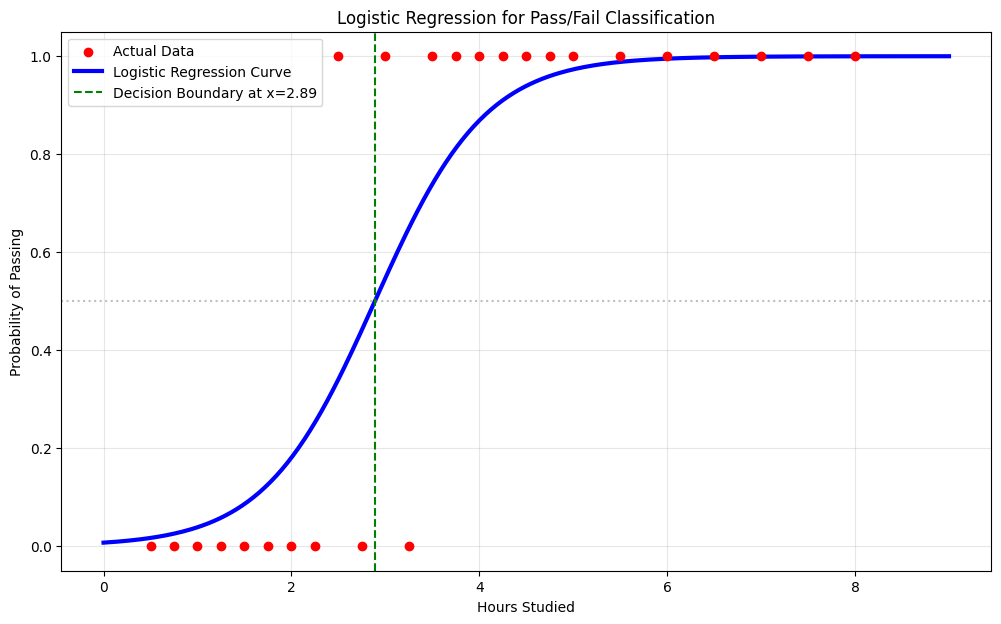

In [37]:
plt.figure(figsize=(12, 7))
plt.scatter(hours_studied, pass_fail, color='red', zorder=20, label='Actual Data')

x_test = np.linspace(0, 9, 300).reshape(-1, 1)
y_prob = model.predict_proba(x_test)[:, 1]
plt.plot(x_test, y_prob, color='blue', linewidth=3, label='Logistic Regression Curve')

boundary = -model.intercept_[0] / model.coef_[0][0]
plt.axvline(x=boundary, color='green', linestyle='--', label=f'Decision Boundary at x={boundary:.2f}')
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)

plt.ylabel('Probability of Passing')
plt.xlabel('Hours Studied')
plt.title('Logistic Regression for Pass/Fail Classification')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

## 6. Streaming Logic (Rubric Level 5)

This section implements the streaming logic that reads exactly one record at a time, every 2 seconds, from the source and passes it to the database. This simulates real-time data ingestion.

In [38]:
def stream_records(db_name='study_records.db', delay=2):
    """
    Stream records from the database one at a time.
    
    Parameters:
    db_name: Name of the SQLite database
    delay: Time delay between records (seconds)
    
    Yields:
    tuple: (id, hours_studied, pass_fail, timestamp)
    """
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    
    cursor.execute('SELECT id, hours_studied, pass_fail, timestamp FROM study_records ORDER BY id')
    records = cursor.fetchall()
    
    for record in records:
        yield record
        time.sleep(delay)
    
    conn.close()

---

## 7. Dynamic Dashboard (Rubric Level 5)

This section builds a dynamic dashboard using IPyWidgets that updates in real-time as the 2-second stream progresses. The dashboard shows:
- Current record being processed
- Live prediction
- Running statistics

In [39]:
class DynamicDashboard:
    """
    Dynamic dashboard for real-time streaming data visualization.
    Uses IPyWidgets for interactive updates.
    """
    
    def __init__(self, model):
        self.model = model
        self.stream_data = []
        self.predictions = []
        self.actual = []
        
        self.setup_widgets()
    
    def setup_widgets(self):
        """Initialize the dashboard widgets."""
        self.output = widgets.Output()
        
        self.status_label = widgets.Label(value='Status: Waiting to start...')
        self.record_label = widgets.HTML(value='<b>Current Record:</b> -')
        self.prediction_label = widgets.HTML(value='<b>Prediction:</b> -')
        self.count_label = widgets.Label(value='Records Processed: 0')
        self.accuracy_label = widgets.Label(value='Current Accuracy: -')
        
        self.start_button = widgets.Button(description='Start Stream', button_style='success')
        self.start_button.on_click(self.start_stream)
        
        self.dashboard_box = widgets.VBox([
            widgets.HTML('<h2>📊 Real-Time Logistic Regression Dashboard</h2>'),
            self.status_label,
            self.record_label,
            self.prediction_label,
            self.count_label,
            self.accuracy_label,
            self.start_button,
            self.output
        ])
    
    def display(self):
        """Display the dashboard."""
        display(self.dashboard_box)
    
    def start_stream(self, b):
        """Start the streaming process."""
        self.start_button.disabled = True
        self.status_label.value = 'Status: Streaming...'
        self.stream_and_update()
    
    def stream_and_update(self):
        """Stream records and update the dashboard."""
        for record in stream_records(delay=2):
            record_id, hours, actual, timestamp = record
            
            self.stream_data.append(record)
            self.actual.append(actual)
            
            hours_array = np.array([[hours]])
            prediction = self.model.predict(hours_array)[0]
            prob = self.model.predict_proba(hours_array)[0]
            
            self.predictions.append(prediction)
            
            with self.output:
                clear_output(wait=True)
                
                fig, axes = plt.subplots(1, 2, figsize=(12, 4))
                
                ax1 = axes[0]
                x_range = np.linspace(0, 9, 100).reshape(-1, 1)
                y_prob = self.model.predict_proba(x_range)[:, 1]
                ax1.plot(x_range, y_prob, 'b-', linewidth=2, label='Sigmoid Curve')
                ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
                ax1.scatter([hours], [prob[1]], color='red', s=100, zorder=5, label='Current Point')
                ax1.set_xlabel('Hours Studied')
                ax1.set_ylabel('Pass Probability')
                ax1.set_title('Live Prediction')
                ax1.legend()
                ax1.grid(True, alpha=0.3)
                
                ax2 = axes[1]
                if len(self.actual) > 0:
                    correct = sum(1 for a, p in zip(self.actual, self.predictions) if a == p)
                    acc = correct / len(self.actual) * 100
                else:
                    acc = 0
                ax2.bar(['Processed'], [len(self.actual)], color='steelblue')
                ax2.bar(['Correct'], [correct], color='green')
                ax2.set_ylabel('Count')
                ax2.set_title(f'Accuracy: {acc:.1f}%')
                
                plt.tight_layout()
                plt.show()
            
            self.record_label.value = f'<b>Record #{record_id}</b>: Hours={hours}, Actual={"Pass" if actual == 1 else "Fail"}'
            self.prediction_label.value = f'<b>Prediction:</b> {"Pass" if prediction == 1 else "Fail"} (Prob: {prob[1]:.2f})'
            self.count_label.value = f'Records Processed: {len(self.stream_data)}'
            
            if len(self.actual) > 0:
                correct = sum(1 for a, p in zip(self.actual, self.predictions) if a == p)
                acc = correct / len(self.actual) * 100
                self.accuracy_label.value = f'Current Accuracy: {acc:.1f}%'
        
        self.status_label.value = 'Status: Stream Complete!'
        self.start_button.disabled = False

In [40]:
dashboard = DynamicDashboard(model)
dashboard.display()

---

## 8. Prediction Example

Example predictions using the trained model.

In [41]:
def predict_study_outcome(hours, model):
    """
    Predict pass/fail outcome for given study hours.
    
    Parameters:
    hours: Number of hours studied
    model: Trained logistic regression model
    
    Returns:
    tuple: (prediction, probability)
    """
    hours_array = np.array([[hours]])
    prob = model.predict_proba(hours_array)[0]
    prediction = model.predict(hours_array)[0]
    
    return prediction, prob

In [42]:
test_hours = [1.5, 2.5, 3.5, 4.5, 5.5]

print("Prediction Examples:")
print("-" * 50)
for hours in test_hours:
    pred, prob = predict_study_outcome(hours, model)
    outcome = "PASS" if pred == 1 else "FAIL"
    print(f"Hours: {hours:.1f} -> Prediction: {outcome} (Pass Prob: {prob[1]:.3f})")

Prediction Examples:
--------------------------------------------------
Hours: 1.5 -> Prediction: FAIL (Pass Prob: 0.086)
Hours: 2.5 -> Prediction: FAIL (Pass Prob: 0.341)
Hours: 3.5 -> Prediction: PASS (Pass Prob: 0.739)
Hours: 4.5 -> Prediction: PASS (Pass Prob: 0.939)
Hours: 5.5 -> Prediction: PASS (Pass Prob: 0.988)


---

## 9. Summary

This workshop demonstrated:

1. **Logistic Regression**: Used to model the probability of passing based on study hours
2. **Pipeline Pattern**: Implemented modular functions (load_data, preprocess_data, train_model, evaluate_model)
3. **SQLite Database**: Created and populated with historical study records
4. **Streaming Logic**: Implemented 2-second interval record streaming
5. **Dynamic Dashboard**: IPyWidgets-based real-time visualization

The model learns the relationship between study hours and exam outcomes, using the sigmoid function to estimate the probability of passing. By applying a 0.5 threshold, we classify each student as passing or failing.